In [2]:
import os

# This checks if your photos are "buried" in a subfolder
if 'blanket' in os.listdir('raw_data/blanket'):
    print("Photos are in a subfolder. Fixing the path...")
    # This moves them up one level so the script can see them
    !mv raw_data/blanket/blanket/* raw_data/blanket/
    !mv raw_data/teddy_bear/teddy/* raw_data/teddy_bear/
    print("Done! Photos moved to the correct spot.")
else:
    print("Photos are exactly where they need to be!")


Photos are in a subfolder. Fixing the path...
Done! Photos moved to the correct spot.


In [3]:
import os
import random
import shutil

# 1. UPDATED PATHS to match your folders exactly
source_dir = 'raw_data' # This folder has 'blanket' and 'teddy_bear' inside
target_dir = 'data'

def split_my_donations(src, dest, split=0.8):
    # Match the folder names you created earlier
    classes = ['blanket', 'teddy_bear']

    for c in classes:
        # Create the folders
        os.makedirs(os.path.join(dest, 'train', c), exist_ok=True)
        os.makedirs(os.path.join(dest, 'validation', c), exist_ok=True)

        # Path to where your photos are
        path = os.path.join(src, c)

        if not os.path.exists(path):
            print(f"Warning: Could not find {path}. Check your folder structure.")
            continue

        # Get all images and shuffle them
        images = [f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        random.shuffle(images)

        # Split into 80% train, 20% validation
        limit = int(len(images) * split)
        for i, img in enumerate(images):
            folder = 'train' if i < limit else 'validation'
            shutil.copy(os.path.join(path, img), os.path.join(dest, folder, c, img))

    print("Success! Folders are now ready for the ResNet50 model!")

# Run the split
split_my_donations(source_dir, target_dir)


Success! Folders are now ready for the ResNet50 model!


Found 278 images belonging to 3 classes.
Found 71 images belonging to 3 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Starting training...
Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 124s 12s/step - accuracy: 0.3813 - loss: 1.1187 - val_accuracy: 0.6761 - val_loss: 0.6572
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 122s 10s/step - accuracy: 0.5540 - loss: 0.9191 - val_accuracy: 0.6761 - val_loss: 0.6219
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 93s 10s/step - accuracy: 0.6439 - loss: 0.8520 - val_accuracy: 0.6761 - val_loss: 0.6230
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 94s 10s/step - accuracy: 0.5576 - loss: 0.9032 - val_accuracy: 0.6761 - val_loss: 0.6358
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 94s 10s/step - accuracy: 0.5396 - loss: 0.9059 - val_accuracy: 0.6761 - val_loss: 0.6377
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 94s 11s/step - accuracy: 0.5468 - loss: 0.8503 - val_accuracy: 0.6761 - val_loss: 0.6226
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 92s 10s/step - accuracy: 0.6187 - loss: 0.8450 - val_accura

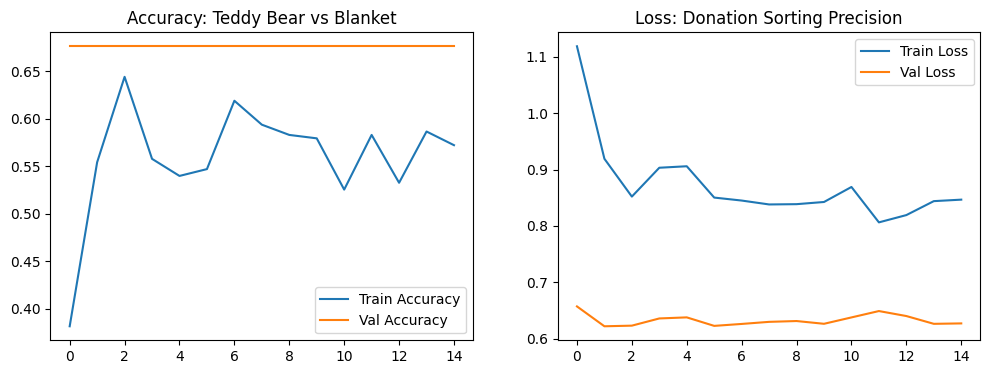

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt

# 1. SETUP
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32

# 2. DATA AUGMENTATION (Handles 'scrunched' blankets and different views)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

# 3. LOAD ORGANIZED DATA
train_generator = train_datagen.flow_from_directory(
    'data/train',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    'data/validation',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# 4. BUILD MODEL (Transfer Learning)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# 5. COMPILE & CLASS WEIGHTS (To balance your 125 extra blanket images)
model.compile(optimizer=optimizers.Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
class_weight = {0: 1.0, 1: 1.5} # 0=Blanket, 1=Teddy Bear

# 6. TRAIN
print("Starting training...")
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    class_weight=class_weight
)

# 7. VISUALIZE RESULTS
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy: Teddy Bear vs Blanket')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss: Donation Sorting Precision')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


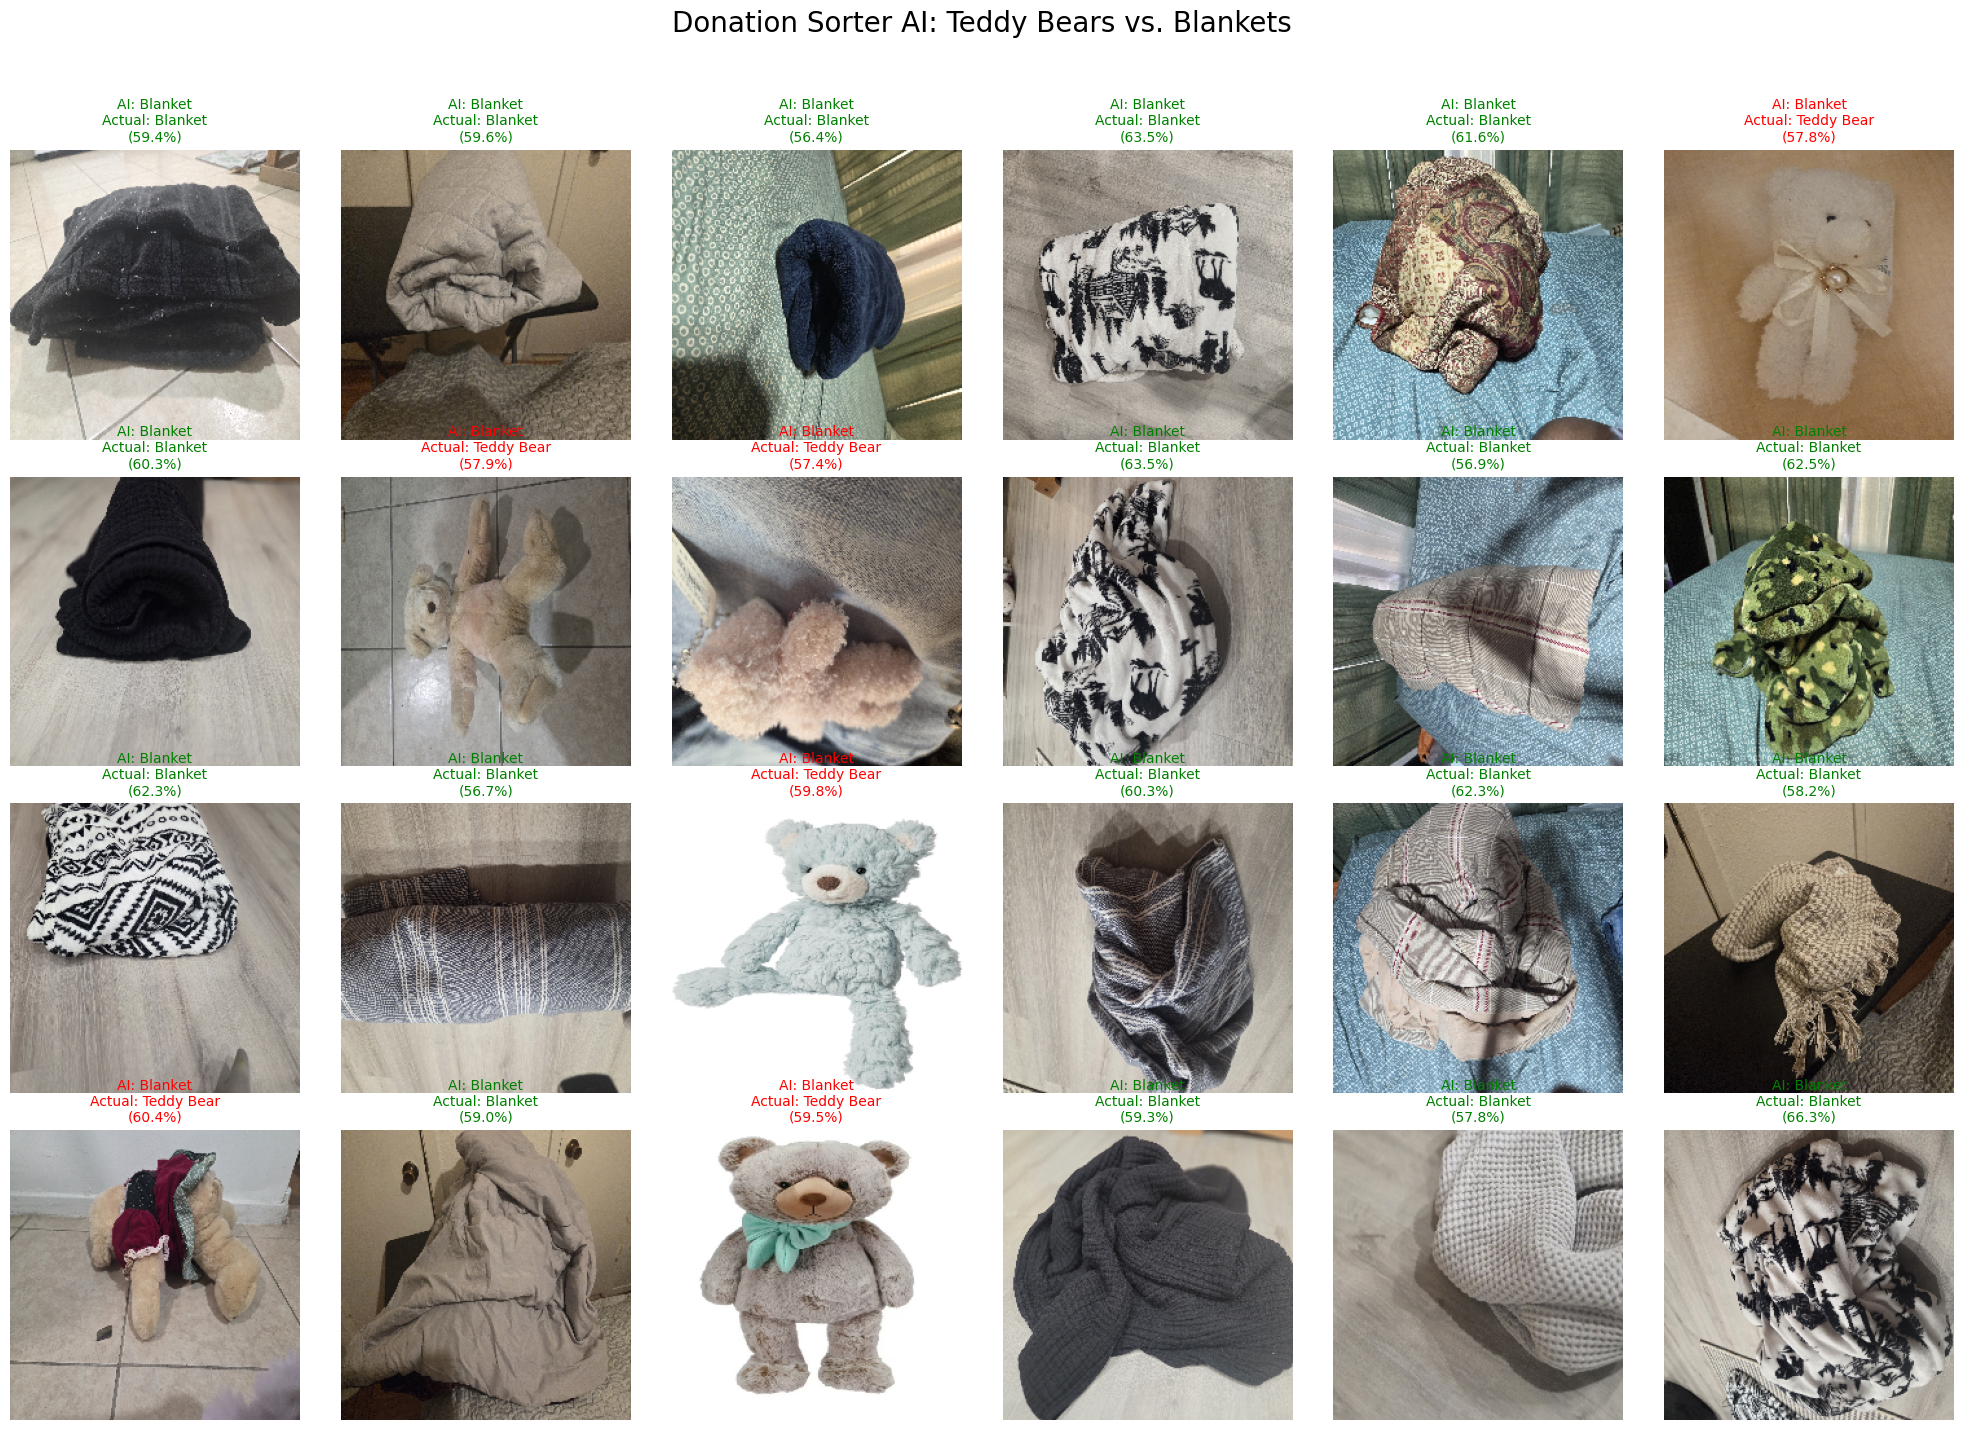

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Get a batch of images and labels from the validation set
# This picks random photos the model HAS NOT seen during training
v_images, v_labels = next(val_generator)

# 2. Make predictions
# ResNet50 will output a probability (e.g., 0.85 bear)
predictions = model.predict(v_images)

# 3. Create the Visual Chart (6x4 grid for 24 images)
plt.figure(figsize=(20, 15))
plt.suptitle("Donation Sorter AI: Teddy Bears vs. Blankets", fontsize=20)

for i in range(24):
    plt.subplot(4, 6, i + 1)
    plt.imshow(v_images[i])

    # Logic for labeling
    # If the generator used binary mode, 1 is typically Bear and 0 is Blanket
    actual_label = "Teddy Bear" if v_labels[i] == 1 else "Blanket"
    predicted_label = "Teddy Bear" if predictions[i] > 0.5 else "Blanket"

    # Green for correct, Red for mistakes (just like your labs!)
    title_color = 'green' if actual_label == predicted_label else 'red'

    # Show the AI's confidence percentage
    confidence = predictions[i][0] if predicted_label == "Teddy Bear" else 1 - predictions[i][0]

    plt.title(f"AI: {predicted_label}\nActual: {actual_label}\n({confidence*100:.1f}%)", color=title_color, fontsize=10)
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
